In [4]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_DA_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

In [6]:
df_plot = df_DA_In['job_location'].value_counts().head(10).to_frame()

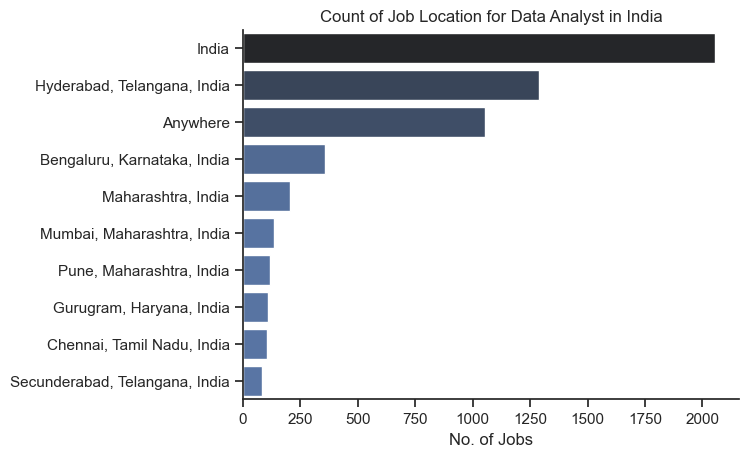

In [7]:
df_plot = df_DA_In['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count',y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Job Location for Data Analyst in India')
plt.ylabel('')
plt.xlabel('No. of Jobs')
plt.show()

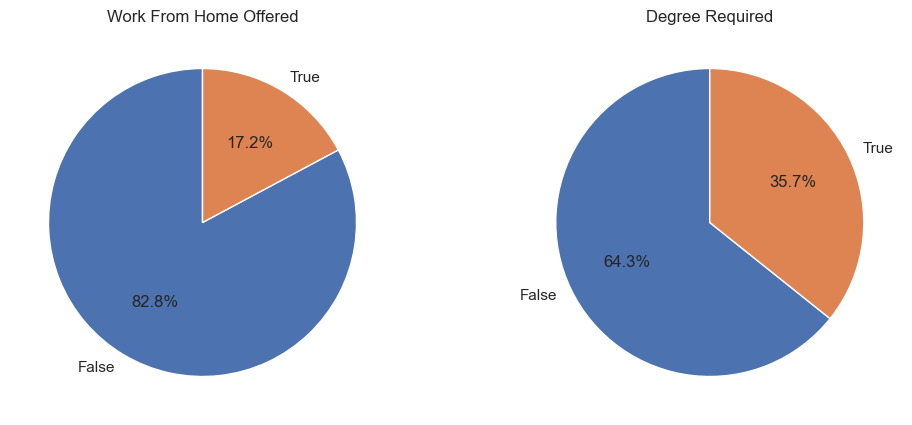

In [8]:
dict_column = {
    'job_work_from_home': 'Work From Home Offered',
    'job_no_degree_mention': 'Degree Required'
}

fig, ax = plt.subplots(1,2)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_In[column].value_counts(), labels= ['False','True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()


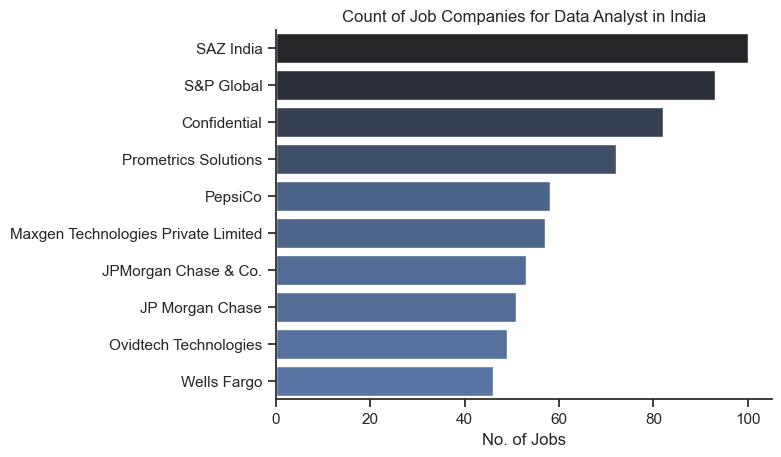

In [9]:
df_plot = df_DA_In['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count',y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Job Companies for Data Analyst in India')
plt.ylabel('')
plt.xlabel('No. of Jobs')
plt.show()